In [1]:
using Pkg

cd(@__DIR__)
Pkg.activate("../")

using Dates, SonifSismo, CairoMakie

  Activating project at `c:\Users\lucie\Desktop\sonifSismo.jl-main`


In [2]:
archive = DataArchive("C:/Users/lucie/Desktop/mtFujiContinuous/mtFujiContinuous")

DataArchive("C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\catalog\\h2008", :JST, Hour(9))

In [3]:
available_stations(archive)      # Affiche les stations disponibles dans l'archive
available_channels(archive)      # Affiche les canaux disponibles dans l'archive

33-element Vector{ChannelAvailability}:
 ChannelAvailability("EV", "FJO", "", "E", [Date("2008-05-25"), Date("2008-05-26"), Date("2008-05-27"), Date("2008-05-28"), Date("2008-05-29"), Date("2008-05-30"), Date("2008-05-31")], ["C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\25\\EV.FJO..E.20080525.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\26\\EV.FJO..E.20080526.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\27\\EV.FJO..E.20080527.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\28\\EV.FJO..E.20080528.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\29\\EV.FJO..E.20080529.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\30\\EV.FJO..E.20080530.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\31\\EV.FJO..E.2008053

In [4]:
startTime = DateTime(2008, 5, 28, 0, 0, 0)
stopTime = DateTime(2008, 5, 28, 23, 59, 59)

events = read_catalog(
    archive;
    start=startTime,          # Début de la période = début de la journée
    stop=stopTime,            # Fin de la période = fin de la journée
    min_magnitude=2.0,        # Magnitude minimale
    max_depth=50.0,           # Profondeur maximale
)

traces = read_window(              # Lire les traces associées à la journée entière
    archive,
    startTime,
    stopTime;                      # Bien mettre le point virgule APRES les arguments temporels
    stations="FUJ",                # Station de Fuji
    channels=["wE", "wN", "wU"],   # Composantes E (Est-Ouest), N (Nord-Sud) et U (Haut-Bas)
    processed=true,
    bandpass=(0.5, 15.0),          # Filtre passe-bande entre 0.5 et 15 Hz
)

3-element Vector{Seis.AbstractTrace}:
 Seis.Trace(EV.FUJ..wE : delta=0.01, b=0.0, nsamples=8639901)
 Seis.Trace(EV.FUJ..wN : delta=0.01, b=0.0, nsamples=8639901)
 Seis.Trace(EV.FUJ..wU : delta=0.01, b=0.0, nsamples=8639901)

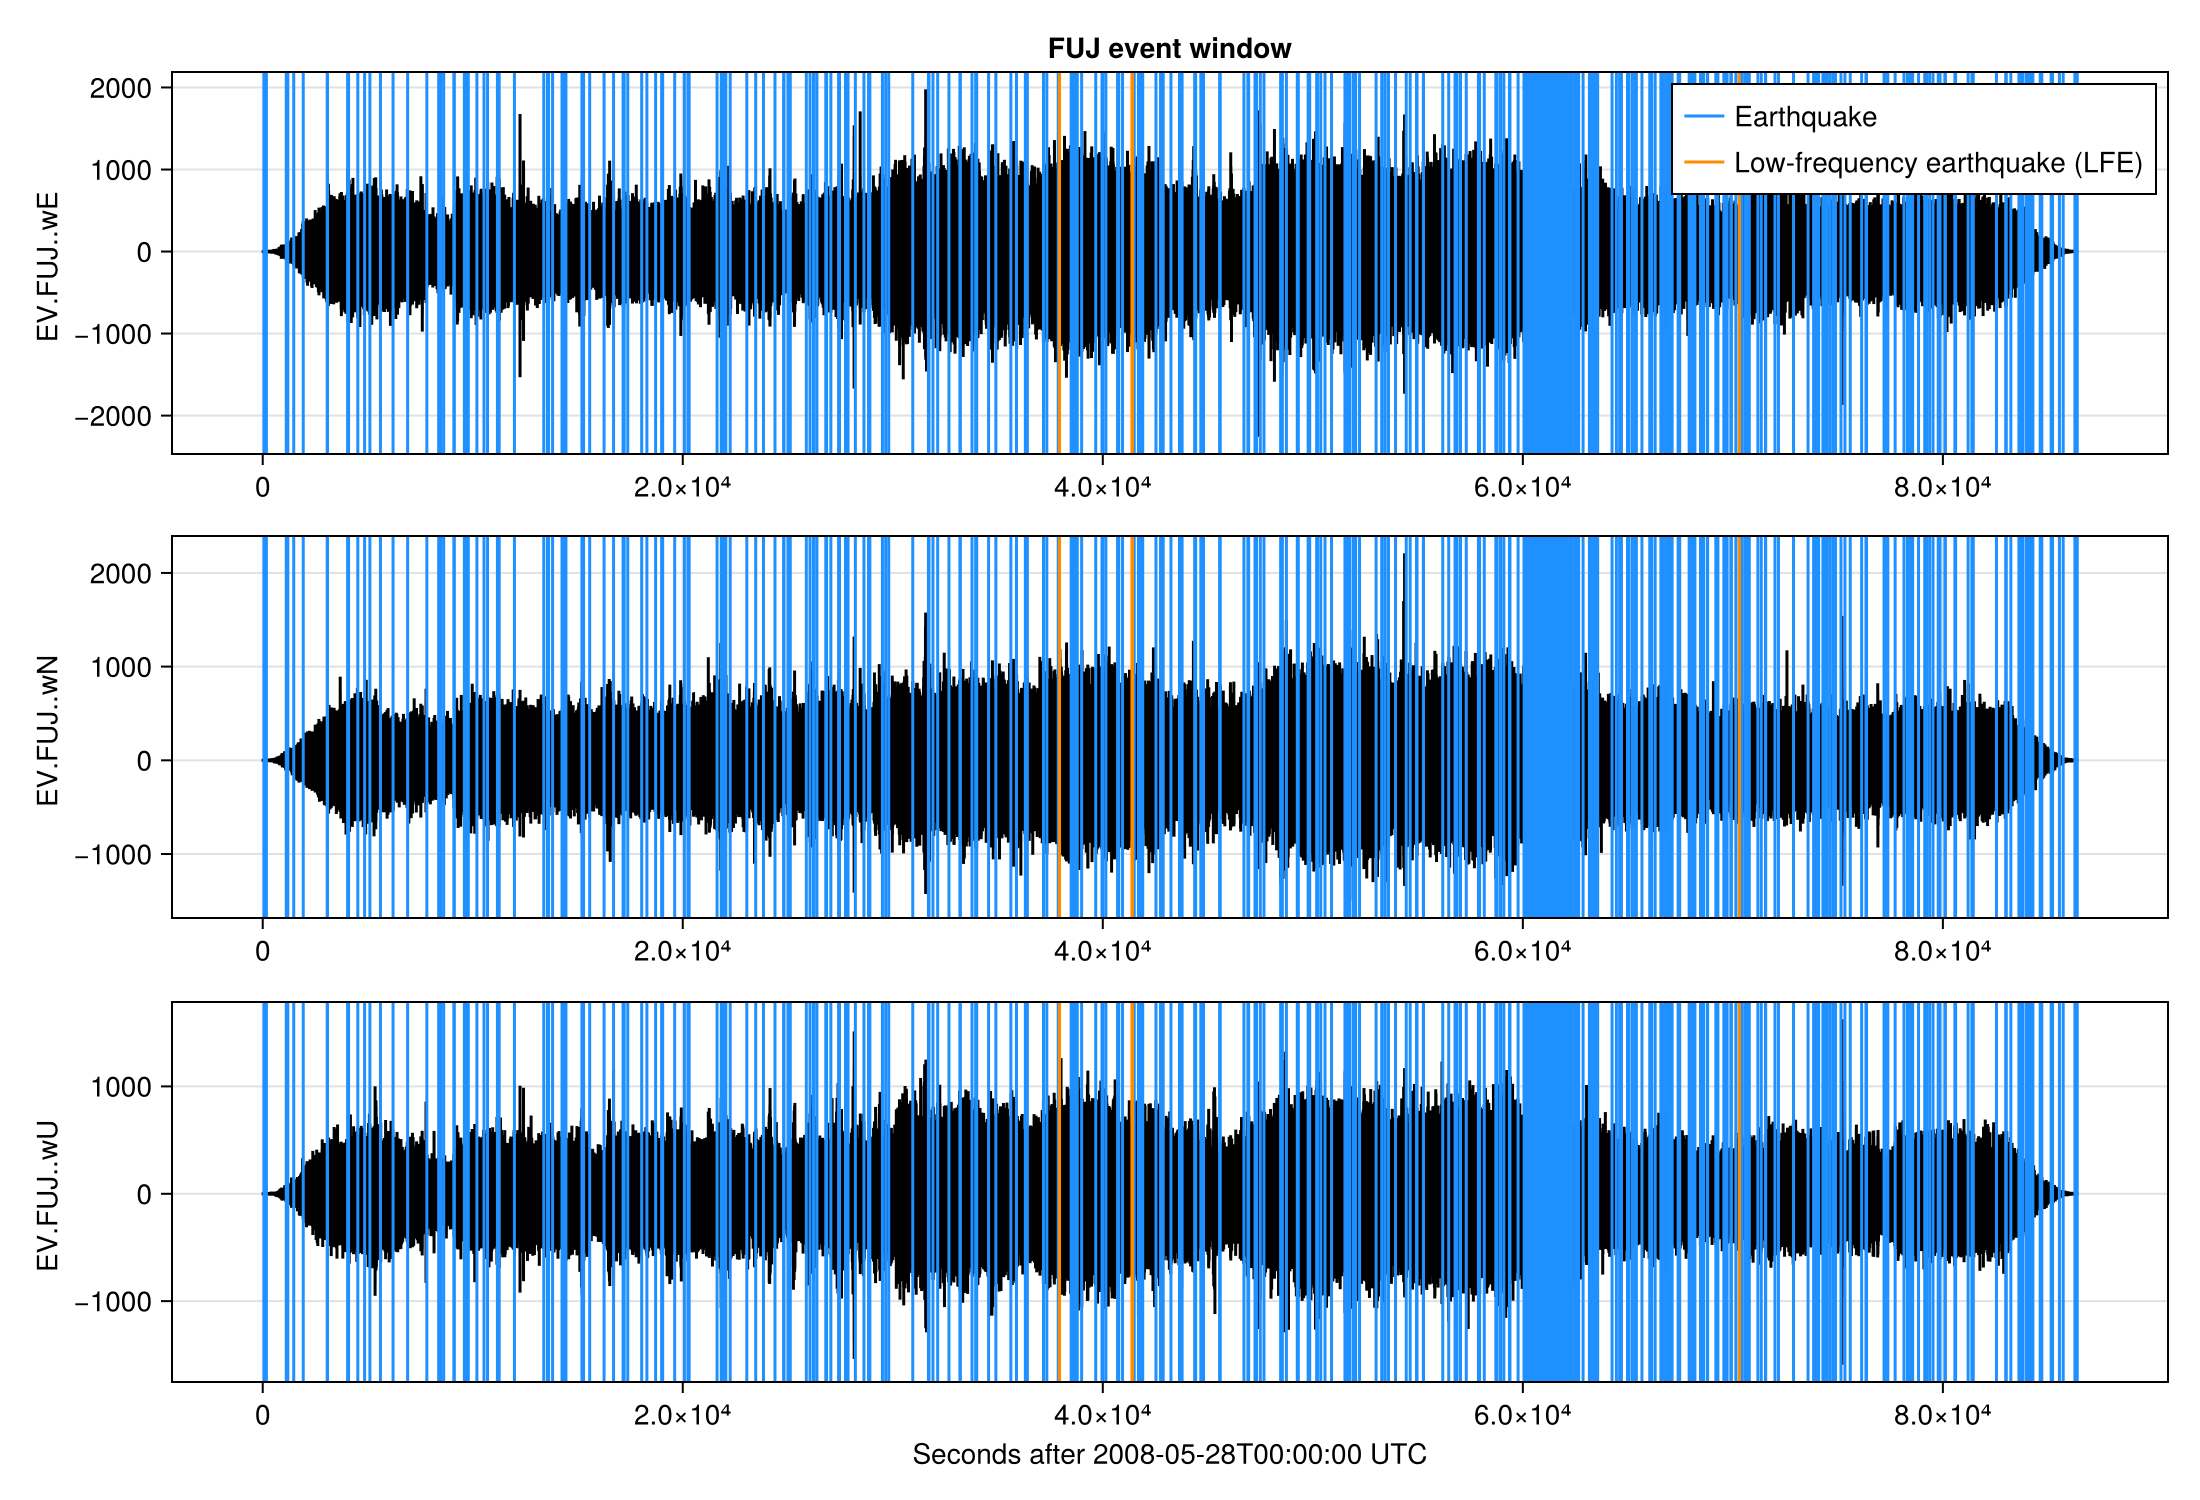

In [5]:
event = first(events)

plot_events = read_catalog(      # Lire les événements pour la période spécifiée
    archive;
    start=startTime,
    stop=stopTime,
)

wavefig = plot_waveforms(        # Afficher les formes d'ondes des traces
    traces;
    events=plot_events,
    title="FUJ event window",
)
wavefig

In [6]:
save("C:/Users/lucie/Desktop/Sonification/28 mai.png", wavefig)

In [10]:
specfig = plot_time_frequency(
    traces;
    events=plot_events,
    window=2.0,
    overlap=0.75,
    title="FUJ time-frequency power",
)

display(specfig)

CairoMakie.Screen{IMAGE}


In [11]:
save("C:/Users/lucie/Desktop/Sonification/28 mai Frequency power.png", specfig)

ErrorException: Cairo stops rendering images bigger than 32745, which is likely a bug in Cairo. Please resample your image/heatmap with heatmap(Resampler(data)).